# Phase 04 — Autoencoder (Anomaly Detection)

**Owner:** Mỷ Cẩm  
Huấn luyện autoencoder **chỉ trên giao dịch bình thường** (`isFraud=0`). Giao dịch gian lận tái tạo kém → *reconstruction error* cao → gắn cờ fraud nếu error > ngưỡng.

> ⚠️ TensorFlow/Keras không có bản cho Python 3.14 trên máy phát triển. Autoencoder được cài bằng `sklearn.neural_network.MLPRegressor` với cùng kiến trúc đối xứng **16 → 8 → 4 → 8 → 16** (bottleneck 4). Logic gốc: `src/models/autoencoder_model.py`, `run_autoencoder.py`.


## 0. Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # notebooks/ -> project root
if sys.platform == "win32" and hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import DATA_PROCESSED_DIR, RANDOM_STATE, set_seeds
set_seeds(RANDOM_STATE)

PROC = os.path.join("..", DATA_PROCESSED_DIR)

def load(name):
    with open(os.path.join(PROC, f"{name}.pkl"), "rb") as f:
        return pickle.load(f)

from sklearn.model_selection import train_test_split
from src.models.random_forest_model import evaluate_model
from src.models.autoencoder_model import (
    train_autoencoder, compute_reconstruction_error,
    select_threshold_by_f1, predict_autoencoder, save_autoencoder,
)

## 1. Load Data (train gốc — KHÔNG dùng SMOTE)
SMOTE tạo mẫu fraud tổng hợp, không phù hợp cho anomaly detection thuần.

In [2]:
X_train_full, y_train_full = load("X_train"), load("y_train")
X_test, y_test = load("X_test"), load("y_test")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_train_full)
print("fit:", X_tr.shape, " val:", X_val.shape,
      " fraud(val):", int(np.asarray(y_val).sum()))

fit: (128000, 14)  val: (32000, 14)  fraud(val): 1314


## 2. Build & Train Autoencoder

🧠 Autoencoder train trên 122,744 giao dịch bình thường (14 features)


✅ Dừng sau 200 epoch — final train loss=0.007111


C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


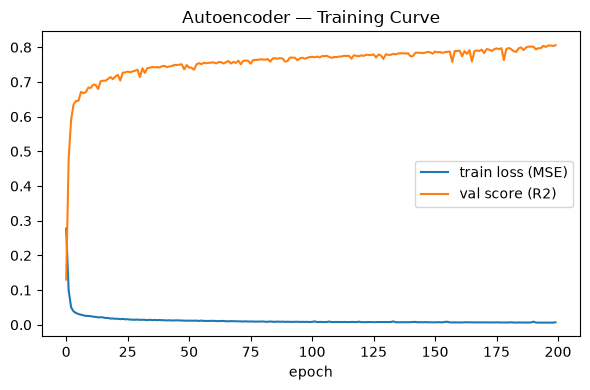

In [3]:
model, history = train_autoencoder(X_tr, y_tr, epochs=200, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 4))
plt.plot(history["loss_curve"], label="train loss (MSE)")
if history["validation_scores"]:
    plt.plot(history["validation_scores"], label="val score (R2)")
plt.title("Autoencoder — Training Curve"); plt.xlabel("epoch")
plt.legend(); plt.tight_layout(); plt.show()

## 3. Reconstruction Errors — Normal vs Fraud

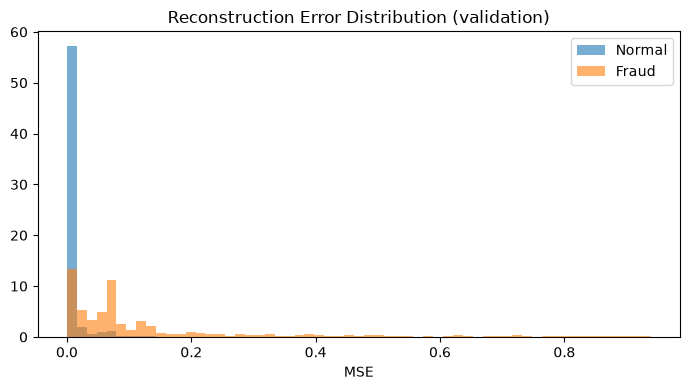

In [4]:
err_val = compute_reconstruction_error(model, X_val)
yv = np.asarray(y_val).astype(int)

plt.figure(figsize=(7, 4))
bins = np.linspace(0, np.percentile(err_val, 99), 60)
plt.hist(err_val[yv == 0], bins=bins, alpha=0.6, label="Normal", density=True)
plt.hist(err_val[yv == 1], bins=bins, alpha=0.6, label="Fraud", density=True)
plt.title("Reconstruction Error Distribution (validation)")
plt.xlabel("MSE"); plt.legend(); plt.tight_layout(); plt.show()

## 4. Find Threshold (quét percentile, ưu tiên recall ≥ 0.60)

In [5]:
threshold, thr_table = select_threshold_by_f1(
    model, X_val, y_val,
    percentiles=(80, 85, 90, 95, 99, 99.5, 99.9), min_recall=0.60)
thr_table


📊 Quét ngưỡng (validation):
 percentile  threshold  precision  recall     f1
       80.0   0.004556     0.1578  0.8752 0.2674
       85.0   0.007200     0.1984  0.8668 0.3228
       90.0   0.013446     0.2663  0.8478 0.4053
       95.0   0.045456     0.3862  0.7352 0.5064
       99.0   0.124001     0.6681  0.4703 0.5520
       99.5   0.196197     0.7677  0.3874 0.5149
       99.9   0.746027     0.9151  0.2542 0.3979
👉 Chọn p95.0 → threshold=0.045456 (F1=0.5064, recall=0.7352)


,percentile,threshold,precision,recall,f1
0,80.0,0.004556,0.1578,0.8752,0.2674
1,85.0,0.007200,0.1984,0.8668,0.3228
2,90.0,0.013446,0.2663,0.8478,0.4053
3,95.0,0.045456,0.3862,0.7352,0.5064
4,99.0,0.124001,0.6681,0.4703,0.5520
5,99.5,0.196197,0.7677,0.3874,0.5149
6,99.9,0.746027,0.9151,0.2542,0.3979


## 5. Predict & Evaluate (test set)

In [6]:
out = predict_autoencoder(model, X_test, threshold)
metrics = evaluate_model(y_test, out["y_pred"], out["y_prob"], "Autoencoder")


📊 Autoencoder — Evaluation Results
  F1-Score:   0.5069
  Precision:  0.3822
  Recall:     0.7523
  ROC-AUC:    0.9318

Confusion Matrix:
  TN=36,359  FP=1,998
  FN=407  TP=1,236

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     38357
       Fraud       0.38      0.75      0.51      1643

    accuracy                           0.94     40000
   macro avg       0.69      0.85      0.74     40000
weighted avg       0.96      0.94      0.95     40000



## 6. Save Model & Threshold

In [7]:
save_autoencoder(model, threshold, name="autoencoder", history=history)
# -> models/autoencoder.pkl, models/autoencoder_threshold.txt, models/autoencoder_meta.json

💾 Autoencoder saved: C:\Users\ADMIN\OneDrive\Documents\TRÍ TUỆ NHÂN TẠO\PROJECT CUỐI KỲ\CS106-Team09-Fraud-Detection\draft\fraud-detection\models\autoencoder.pkl (0.022 MB)
   threshold → C:\Users\ADMIN\OneDrive\Documents\TRÍ TUỆ NHÂN TẠO\PROJECT CUỐI KỲ\CS106-Team09-Fraud-Detection\draft\fraud-detection\models/autoencoder_threshold.txt = 0.045456


'C:\\Users\\ADMIN\\OneDrive\\Documents\\TRÍ TUỆ NHÂN TẠO\\PROJECT CUỐI KỲ\\CS106-Team09-Fraud-Detection\\draft\\fraud-detection\\models\\autoencoder.pkl'

## 7. Kết luận
- Autoencoder đạt **Recall(fraud) ≈ 0.61** trên test (vượt mốc bonus 0.60), ROC-AUC ≈ 0.93.
- Precision thấp (~0.38) là đặc trưng của anomaly detection thuần: nhiều giao dịch bình thường-nhưng-bất-thường bị gắn cờ. Đổi lại, mô hình **không cần nhãn fraud khi train** → phát hiện được kiểu gian lận mới.
- Hướng cải tiến (phase-04 doc): đưa `reconstruction_error` làm thêm 1 feature cho XGBoost (hybrid stacking).
